In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/tasminarahmanshifa/rice-leaf-and-crop-disease-dataset/Tungro/orginal/20241114_150555.jpg
/kaggle/input/datasets/tasminarahmanshifa/rice-leaf-and-crop-disease-dataset/Tungro/orginal/20241114_145527.jpg
/kaggle/input/datasets/tasminarahmanshifa/rice-leaf-and-crop-disease-dataset/Tungro/orginal/IMG_20241114_144634.jpg
/kaggle/input/datasets/tasminarahmanshifa/rice-leaf-and-crop-disease-dataset/Tungro/orginal/IMG_20241114_155701.jpg
/kaggle/input/datasets/tasminarahmanshifa/rice-leaf-and-crop-disease-dataset/Tungro/orginal/IMG_20241114_154546.jpg
/kaggle/input/datasets/tasminarahmanshifa/rice-leaf-and-crop-disease-dataset/Tungro/orginal/IMG_20241114_161614.jpg
/kaggle/input/datasets/tasminarahmanshifa/rice-leaf-and-crop-disease-dataset/Tungro/orginal/20241114_150917.jpg
/kaggle/input/datasets/tasminarahmanshifa/rice-leaf-and-crop-disease-dataset/Tungro/orginal/20241114_152001.jpg
/kaggle/input/datasets/tasminarahmanshifa/rice-leaf-and-crop-disease-dataset/Tungro/orgi

In [2]:
# ── Cell 1 — Install packages ────────────────────────────────
!pip install -q grad-cam timm tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 57.5 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [4]:
# ── Cell 2 — Imports + Seed ──────────────────────────────────
import os
import time
import random
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
import timm

from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

from torchvision import datasets, transforms, models
from torchvision.models import (
    MobileNet_V3_Small_Weights,
    EfficientNet_B0_Weights,
    ResNet18_Weights,
    DenseNet121_Weights
)
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [5]:
for root, dirs, files in os.walk('/kaggle/input/datasets'):
    print(root)

/kaggle/input/datasets
/kaggle/input/datasets/tasminarahmanshifa
/kaggle/input/datasets/tasminarahmanshifa/rice-leaf-and-crop-disease-dataset
/kaggle/input/datasets/tasminarahmanshifa/rice-leaf-and-crop-disease-dataset/Tungro
/kaggle/input/datasets/tasminarahmanshifa/rice-leaf-and-crop-disease-dataset/Tungro/orginal
/kaggle/input/datasets/tasminarahmanshifa/rice-leaf-and-crop-disease-dataset/Tungro/augmented
/kaggle/input/datasets/tasminarahmanshifa/rice-leaf-and-crop-disease-dataset/Tungro/augmented/Aug Tungro
/kaggle/input/datasets/tasminarahmanshifa/rice-leaf-and-crop-disease-dataset/Rice Blast
/kaggle/input/datasets/tasminarahmanshifa/rice-leaf-and-crop-disease-dataset/Rice Blast/orginal
/kaggle/input/datasets/tasminarahmanshifa/rice-leaf-and-crop-disease-dataset/Rice Blast/orginal/Rice Blast
/kaggle/input/datasets/tasminarahmanshifa/rice-leaf-and-crop-disease-dataset/Rice Blast/augmented
/kaggle/input/datasets/tasminarahmanshifa/rice-leaf-and-crop-disease-dataset/Rice Blast/augmen

In [6]:
# ── Cell 3 — Device + Paths ──────────────────────────────────
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

BASE_PATH = "/kaggle/input/datasets/tasminarahmanshifa/rice-leaf-and-crop-disease-dataset"
DATASET   = BASE_PATH
FILTERED  = "/kaggle/working/filtered_dataset"
OUT_DIR   = "/kaggle/working/paper_outputs"

os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(os.path.join(OUT_DIR, "plots"),       exist_ok=True)
os.makedirs(os.path.join(OUT_DIR, "gradcam"),     exist_ok=True)
os.makedirs(os.path.join(OUT_DIR, "checkpoints"), exist_ok=True)

print("\n--- DATASET ---")
print(os.listdir(DATASET))

Device: cuda
GPU: Tesla T4

--- DATASET ---
['Tungro', 'Rice Blast', 'Healthy _leaf', 'Bacterial Leaf Blight', 'Rice']


In [7]:
# ── Cell 4 — Config ──────────────────────────────────────────
BATCH_SIZE           = 16
CNN_EPOCHS           = 20
DL_EPOCHS            = 20
TRANSFORMER_EPOCHS   = 25

print(f"Batch: {BATCH_SIZE} | CNN: {CNN_EPOCHS} | DL: {DL_EPOCHS} | Transformer: {TRANSFORMER_EPOCHS}")

Batch: 16 | CNN: 20 | DL: 20 | Transformer: 25


In [8]:
# ── Cell 5 — Dataset Filtering ───────────────────────────────
classes_keep = [
    "Bacterial Leaf Blight",
    "Rice Blast",
    "Tungro",
    "Healthy _leaf"
]

if os.path.exists(FILTERED):
    shutil.rmtree(FILTERED)
os.makedirs(FILTERED, exist_ok=True)

for c in classes_keep:
    src = os.path.join(DATASET, c)
    dst = os.path.join(FILTERED, c)
    if os.path.exists(src):
        shutil.copytree(src, dst, dirs_exist_ok=True)
        print(f"Copied: {c}")
    else:
        print(f"Missing: {src}")

print("\nFiltered dataset ready.")

from pathlib import Path

total  = 0
counts = {}

for cls in classes_keep:
    cls_path = Path(FILTERED) / cls
    imgs = (list(cls_path.rglob("*.jpg")) +
            list(cls_path.rglob("*.png")) +
            list(cls_path.rglob("*.jpeg")))
    counts[cls] = len(imgs)
    total += len(imgs)
    print(f"  {cls:<25} → {len(imgs):>5} images")

print(f"\n  {'TOTAL':<25} → {total:>5} images")

ratio = counts[max(counts, key=counts.get)] / counts[min(counts, key=counts.get)]
print(f"\n  Imbalance ratio: {ratio:.2f}x")

Copied: Bacterial Leaf Blight
Copied: Rice Blast
Copied: Tungro
Copied: Healthy _leaf

Filtered dataset ready.
  Bacterial Leaf Blight     →   978 images
  Rice Blast                →  3343 images
  Tungro                    →  3745 images
  Healthy _leaf             →  1372 images

  TOTAL                     →  9438 images

  Imbalance ratio: 3.83x


In [10]:
# ── Cell 6 — Transforms ──────────────────────────────────────
train_tf = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2,
                           saturation=0.1, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

test_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [11]:

# ── Cell 7 — Stratified Split ────────────────────────────────
dataset_full = datasets.ImageFolder(FILTERED, transform=train_tf)
targets  = np.array(dataset_full.targets)
indices  = np.arange(len(targets))




train_idx, temp_idx = train_test_split(
    indices, test_size=0.2, stratify=targets, random_state=42
)
temp_targets = targets[temp_idx]
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.5, stratify=temp_targets, random_state=42
)

train_dataset = datasets.ImageFolder(FILTERED, transform=train_tf)
val_dataset   = datasets.ImageFolder(FILTERED, transform=test_tf)
test_dataset  = datasets.ImageFolder(FILTERED, transform=test_tf)

train_ds = Subset(train_dataset, train_idx)
val_ds   = Subset(val_dataset,   val_idx)
test_ds  = Subset(test_dataset,  test_idx)

class_names = train_dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)
print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

Classes: ['Bacterial Leaf Blight', 'Healthy _leaf', 'Rice Blast', 'Tungro']
Train: 7550 | Val: 944 | Test: 944


In [12]:
# ── Cell 8 — DataLoaders + Class Weights + Sampler ───────────
train_targets = np.array([train_dataset.targets[i] for i in train_idx])
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_targets),
    y=train_targets
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
print("Class weights:", class_weights_tensor)

sample_weights = torch.tensor(
    [class_weights[t] for t in train_targets], dtype=torch.float
)
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=2,
    pin_memory=(device == "cuda")
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=(device == "cuda")
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=(device == "cuda")
)

# Verify balance
sampled_labels = []
for i, (_, y) in enumerate(train_loader):
    sampled_labels.extend(y.numpy().tolist())
    if i >= 200:
        break
c = Counter(sampled_labels)
total_s = sum(c.values())
print("\nSampled distribution:")
for i, cls in enumerate(class_names):
    print(f"  {cls:<25} -> {c[i]} ({c[i]/total_s:.3f})")

Class weights: tensor([2.4137, 1.7190, 0.7059, 0.6300], device='cuda:0')

Sampled distribution:
  Bacterial Leaf Blight     -> 798 (0.248)
  Healthy _leaf             -> 785 (0.244)
  Rice Blast                -> 822 (0.256)
  Tungro                    -> 811 (0.252)


In [13]:
# ── Cell 9 — Shared Functions ────────────────────────────────
def train_model(model, train_loader, val_loader, class_weights_tensor, device,
                epochs=15, lr=3e-4, weight_decay=0.0,
                checkpoint_path="/kaggle/working/model_best.pth",
                optimizer_type="adam", scheduler_type=None,
                model_name="Model"):

    model.to(device)
    loss_fn = nn.CrossEntropyLoss(
    weight=class_weights_tensor,
    label_smoothing=0.1
)

    if optimizer_type == "adamw":
        optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    scheduler = None
    if scheduler_type == "cosine":
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_val_acc = 0.0
    train_losses, val_losses = [], []

    print(f"\n{'='*55}")
    print(f"  Training: {model_name}")
    print(f"{'='*55}")

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        train_correct, train_total = 0, 0

        train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1:02d}/{epochs} [Train]",
                         leave=False, ncols=80, position=0)

        for x, y in train_bar:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            if out.dim() == 4:
                out = out.mean(dim=[2, 3])
            if out.dim() != 2:
                out = out.view(out.size(0), -1)
            loss = loss_fn(out, y)
            loss.backward()
            if optimizer_type == "adamw":
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            running_loss += loss.item()
            train_correct += (out.argmax(1) == y).sum().item()
            train_total   += y.size(0)
            train_bar.set_postfix(loss=f"{loss.item():.4f}")

        epoch_loss = running_loss / len(train_loader)
        train_acc  = train_correct / train_total
        train_losses.append(epoch_loss)

        model.eval()
        correct, total = 0, 0
        val_running_loss = 0.0

        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                if out.dim() == 4:
                    out = out.mean(dim=[2, 3])
                if out.dim() != 2:
                    out = out.view(out.size(0), -1)
                val_running_loss += loss_fn(out, y).item()
                correct += (out.argmax(1) == y).sum().item()
                total   += y.size(0)

        val_acc  = correct / total
        val_loss = val_running_loss / len(val_loader)
        val_losses.append(val_loss)

        if scheduler is not None:
            scheduler.step()

        improved = "✅" if val_acc > best_val_acc else "  "
        print(f"  Epoch {epoch+1:02d}/{epochs} | "
              f"Train Loss: {epoch_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} {improved}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), checkpoint_path)

    print(f"\n  Best Val Acc: {best_val_acc:.4f} — saved to {checkpoint_path}")
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    return model, train_losses, val_losses


def evaluate(model, loader, class_names, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            out = model(x)
            if out.dim() == 4:
                out = out.mean(dim=[2, 3])
            if out.dim() != 2:
                out = out.view(out.size(0), -1)
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_labels.extend(y.numpy())

    report = classification_report(
        all_labels, all_preds,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )
    cm = confusion_matrix(all_labels, all_preds)
    return all_labels, all_preds, report, cm


def model_info(model, device):
    model.eval()
    params  = sum(p.numel() for p in model.parameters())
    size_mb = params * 4 / (1024 ** 2)
    x = torch.randn(1, 3, 224, 224).to(device)

    with torch.inference_mode():
        for _ in range(10):
            _ = model(x)
        if device == "cuda":
            torch.cuda.synchronize()
        start = time.perf_counter()
        for _ in range(100):
            _ = model(x)
        if device == "cuda":
            torch.cuda.synchronize()
        elapsed = time.perf_counter() - start

    latency = elapsed / 100
    fps     = 1 / latency
    return params, size_mb, latency, fps

In [16]:
# ── Cell 10 — Train CNN: MobileNetV3-Small ──────────────────────

model_mobilenet = models.mobilenet_v3_small(weights=MobileNet_V3_Small_Weights.DEFAULT)
model_mobilenet.classifier[3] = nn.Linear(
    model_mobilenet.classifier[3].in_features, num_classes
)
model_mobilenet, mobilenet_train_losses, mobilenet_val_losses = train_model(
    model_mobilenet, train_loader, val_loader,
    class_weights_tensor, device,
    epochs=CNN_EPOCHS,
    lr=3e-4,
    weight_decay=0.01,
    optimizer_type="adamw",
    scheduler_type="cosine",
    checkpoint_path=os.path.join(OUT_DIR, "checkpoints", "mobilenet_best.pth"),
    model_name="MobileNetV3-Small"
)


  Training: MobileNetV3-Small


  Epoch 01/20 | Train Loss: 0.7662 | Train Acc: 0.6313 | Val Loss: 0.8594 | Val Acc: 0.7055 ✅


  Epoch 02/20 | Train Loss: 0.6124 | Train Acc: 0.7638 | Val Loss: 1.1060 | Val Acc: 0.5381   


  Epoch 03/20 | Train Loss: 0.5687 | Train Acc: 0.8117 | Val Loss: 0.7430 | Val Acc: 0.7977 ✅


  Epoch 04/20 | Train Loss: 0.5211 | Train Acc: 0.8560 | Val Loss: 0.7520 | Val Acc: 0.8167 ✅


...

  Epoch 16/20 | Train Loss: 0.4028 | Train Acc: 0.9501 | Val Loss: 0.6233 | Val Acc: 0.9195   


  Epoch 17/20 | Train Loss: 0.3971 | Train Acc: 0.9515 | Val Loss: 0.6194 | Val Acc: 0.9269 ✅


  Epoch 18/20 | Train Loss: 0.3977 | Train Acc: 0.9515 | Val Loss: 0.6159 | Val Acc: 0.9280 ✅


  Epoch 19/20 | Train Loss: 0.3909 | Train Acc: 0.9547 | Val Loss: 0.6190 | Val Acc: 0.9280   


  Epoch 20/20 | Train Loss: 0.3987 | Train Acc: 0.9502 | Val Loss: 0.6177 | Val Acc: 0.9258   

  Best Val Acc: 0.9280 — saved to /kaggle/working/paper_outputs/checkpoints/mobilenet_best.pth


In [23]:
# ── Cell 11 — Train CNN: EfficientNetB0 ──────────────────────
model_eff = models.efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
model_eff.classifier[1] = nn.Linear(
    model_eff.classifier[1].in_features, num_classes
)
model_eff, eff_train_losses, eff_val_losses = train_model(
    model_eff, train_loader, val_loader,
    class_weights_tensor, device,
    epochs=CNN_EPOCHS,
    lr=3e-4,
    weight_decay=0.01,
    optimizer_type="adamw",
    scheduler_type="cosine",
    checkpoint_path=os.path.join(OUT_DIR, "checkpoints", "efficientnet_best.pth"),
    model_name="EfficientNetB0"
)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 144MB/s] 



  Training: EfficientNetB0


  Epoch 01/20 | Train Loss: 0.7366 | Train Acc: 0.6624 | Val Loss: 0.9608 | Val Acc: 0.6716 ✅


  Epoch 02/20 | Train Loss: 0.5924 | Train Acc: 0.7930 | Val Loss: 0.7377 | Val Acc: 0.8167 ✅


...

  Epoch 16/20 | Train Loss: 0.3908 | Train Acc: 0.9584 | Val Loss: 0.6211 | Val Acc: 0.9237   


  Epoch 17/20 | Train Loss: 0.3834 | Train Acc: 0.9600 | Val Loss: 0.6188 | Val Acc: 0.9258   


  Epoch 18/20 | Train Loss: 0.3866 | Train Acc: 0.9583 | Val Loss: 0.6224 | Val Acc: 0.9258   


  Epoch 19/20 | Train Loss: 0.3836 | Train Acc: 0.9633 | Val Loss: 0.6265 | Val Acc: 0.9258   


  Epoch 20/20 | Train Loss: 0.3778 | Train Acc: 0.9648 | Val Loss: 0.6311 | Val Acc: 0.9237   

  Best Val Acc: 0.9269 — saved to /kaggle/working/paper_outputs/checkpoints/efficientnet_best.pth


In [17]:
# ── Cell 12 — Train DL Baseline: ResNet18 ────────────────────
model_resnet = models.resnet18(weights=ResNet18_Weights.DEFAULT)
model_resnet.fc = nn.Linear(
    model_resnet.fc.in_features, num_classes
)
model_resnet, resnet_train_losses, resnet_val_losses = train_model(
    model_resnet, train_loader, val_loader,
    class_weights_tensor, device,
    epochs=DL_EPOCHS,
    lr=3e-4,
    weight_decay=0.01,
    optimizer_type="adamw",
    scheduler_type="cosine",
    checkpoint_path=os.path.join(OUT_DIR, "checkpoints", "resnet18_best.pth"),
    model_name="ResNet18"
)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 183MB/s]



  Training: ResNet18


  Epoch 01/20 | Train Loss: 0.8434 | Train Acc: 0.5750 | Val Loss: 1.2972 | Val Acc: 0.4047 ✅


  Epoch 02/20 | Train Loss: 0.7371 | Train Acc: 0.6495 | Val Loss: 1.3537 | Val Acc: 0.4237 ✅


...

  Epoch 16/20 | Train Loss: 0.4249 | Train Acc: 0.9330 | Val Loss: 0.6370 | Val Acc: 0.9078 ✅


  Epoch 17/20 | Train Loss: 0.4174 | Train Acc: 0.9389 | Val Loss: 0.6262 | Val Acc: 0.9153 ✅


  Epoch 18/20 | Train Loss: 0.4156 | Train Acc: 0.9397 | Val Loss: 0.6365 | Val Acc: 0.9142   


  Epoch 19/20 | Train Loss: 0.4085 | Train Acc: 0.9453 | Val Loss: 0.6271 | Val Acc: 0.9142   


  Epoch 20/20 | Train Loss: 0.4217 | Train Acc: 0.9408 | Val Loss: 0.6207 | Val Acc: 0.9131   

  Best Val Acc: 0.9153 — saved to /kaggle/working/paper_outputs/checkpoints/resnet18_best.pth


In [18]:
# ── Cell 13 — Train DL Baseline: DenseNet121 ─────────────────
model_densenet = models.densenet121(weights=DenseNet121_Weights.DEFAULT)
model_densenet.classifier = nn.Linear(
    model_densenet.classifier.in_features, num_classes
)
model_densenet, densenet_train_losses, densenet_val_losses = train_model(
    model_densenet, train_loader, val_loader,
    class_weights_tensor, device,
    epochs=DL_EPOCHS,
    lr=3e-4,
    weight_decay=0.01,
    optimizer_type="adamw",
    scheduler_type="cosine",
    checkpoint_path=os.path.join(OUT_DIR, "checkpoints", "densenet121_best.pth"),
    model_name="DenseNet121"
)

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 151MB/s] 



  Training: DenseNet121


  Epoch 01/20 | Train Loss: 0.7859 | Train Acc: 0.6200 | Val Loss: 1.1199 | Val Acc: 0.4682 ✅


  Epoch 02/20 | Train Loss: 0.6574 | Train Acc: 0.7237 | Val Loss: 0.8686 | Val Acc: 0.7044 ✅


...

  Epoch 16/20 | Train Loss: 0.3983 | Train Acc: 0.9535 | Val Loss: 0.6190 | Val Acc: 0.9206   


  Epoch 17/20 | Train Loss: 0.4004 | Train Acc: 0.9518 | Val Loss: 0.6071 | Val Acc: 0.9258   


  Epoch 18/20 | Train Loss: 0.3951 | Train Acc: 0.9548 | Val Loss: 0.6065 | Val Acc: 0.9269   


  Epoch 19/20 | Train Loss: 0.3928 | Train Acc: 0.9572 | Val Loss: 0.6064 | Val Acc: 0.9269   


  Epoch 20/20 | Train Loss: 0.3962 | Train Acc: 0.9543 | Val Loss: 0.6050 | Val Acc: 0.9280 ✅

  Best Val Acc: 0.9280 — saved to /kaggle/working/paper_outputs/checkpoints/densenet121_best.pth


In [19]:
# ── Cell 14 — Train Transformer: ViT-Tiny ────────────────────
model_vit = timm.create_model(
    "vit_tiny_patch16_224", pretrained=True, num_classes=num_classes
)
model_vit, vit_train_losses, vit_val_losses = train_model(
    model_vit, train_loader, val_loader,
    class_weights_tensor, device,
    epochs=TRANSFORMER_EPOCHS,
    lr=1e-4,
    weight_decay=0.01,
    optimizer_type="adamw",
    scheduler_type="cosine",
    checkpoint_path=os.path.join(OUT_DIR, "checkpoints", "vit_best.pth"),
    model_name="ViT-Tiny"
)

model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]


  Training: ViT-Tiny


  Epoch 01/25 | Train Loss: 0.7758 | Train Acc: 0.6215 | Val Loss: 0.9430 | Val Acc: 0.6144 ✅


  Epoch 02/25 | Train Loss: 0.6360 | Train Acc: 0.7454 | Val Loss: 0.7920 | Val Acc: 0.7288 ✅


  Epoch 03/25 | Train Loss: 0.5704 | Train Acc: 0.7987 | Val Loss: 0.8465 | Val Acc: 0.7023   


...

  Epoch 21/25 | Train Loss: 0.3832 | Train Acc: 0.9615 | Val Loss: 0.6593 | Val Acc: 0.9100   


  Epoch 22/25 | Train Loss: 0.3824 | Train Acc: 0.9653 | Val Loss: 0.6528 | Val Acc: 0.9174   


  Epoch 23/25 | Train Loss: 0.3835 | Train Acc: 0.9628 | Val Loss: 0.6651 | Val Acc: 0.9184 ✅


  Epoch 24/25 | Train Loss: 0.3807 | Train Acc: 0.9666 | Val Loss: 0.6625 | Val Acc: 0.9184   


  Epoch 25/25 | Train Loss: 0.3850 | Train Acc: 0.9653 | Val Loss: 0.6619 | Val Acc: 0.9184   

  Best Val Acc: 0.9184 — saved to /kaggle/working/paper_outputs/checkpoints/vit_best.pth


In [20]:
# ── Cell 15 — Train Transformer: Swin-Tiny ───────────────────
class_weights_tensor = torch.tensor(
    compute_class_weight(
        class_weight="balanced",
        classes=np.arange(num_classes),
        y=np.array([train_dataset.targets[i] for i in train_idx])
    ),
    dtype=torch.float
).to(device)

model_swin = timm.create_model(
    "swin_tiny_patch4_window7_224", pretrained=True, num_classes=0
)
in_features = model_swin.num_features

class SwinClassifier(nn.Module):
    def __init__(self, backbone, in_features, num_classes):
        super().__init__()
        self.backbone = backbone
        self.dropout  = nn.Dropout(0.3)
        self.fc       = nn.Linear(in_features, num_classes)

    def forward(self, x):
        x = self.backbone(x)
        if x.dim() == 4:
            x = x.mean(dim=[2, 3])
        elif x.dim() == 3:
            x = x.mean(dim=1)
        x = self.dropout(x)
        return self.fc(x)

model_swin = SwinClassifier(model_swin, in_features, num_classes)
model_swin.to(device)

with torch.no_grad():
    dummy = torch.randn(2, 3, 224, 224).to(device)
    out   = model_swin(dummy)
    print(f"Swin output shape: {out.shape}")

model_swin, swin_train_losses, swin_val_losses = train_model(
    model_swin, train_loader, val_loader,
    class_weights_tensor, device,
    epochs=TRANSFORMER_EPOCHS,
    lr=1e-4,
    weight_decay=0.05,
    optimizer_type="adamw",
    scheduler_type="cosine",
    checkpoint_path=os.path.join(OUT_DIR, "checkpoints", "swin_best.pth"),
    model_name="Swin-Tiny"
)

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Swin output shape: torch.Size([2, 4])

  Training: Swin-Tiny


  Epoch 01/25 | Train Loss: 0.7762 | Train Acc: 0.6132 | Val Loss: 0.8908 | Val Acc: 0.6653 ✅


  Epoch 02/25 | Train Loss: 0.6233 | Train Acc: 0.7597 | Val Loss: 0.7504 | Val Acc: 0.7839 ✅


  Epoch 03/25 | Train Loss: 0.5562 | Train Acc: 0.8266 | Val Loss: 0.7630 | Val Acc: 0.7765   


...

  Epoch 21/25 | Train Loss: 0.3848 | Train Acc: 0.9620 | Val Loss: 0.6254 | Val Acc: 0.9248   


  Epoch 22/25 | Train Loss: 0.3870 | Train Acc: 0.9632 | Val Loss: 0.6125 | Val Acc: 0.9227   


  Epoch 23/25 | Train Loss: 0.3812 | Train Acc: 0.9665 | Val Loss: 0.6139 | Val Acc: 0.9237   


  Epoch 24/25 | Train Loss: 0.3863 | Train Acc: 0.9599 | Val Loss: 0.6128 | Val Acc: 0.9269   


  Epoch 25/25 | Train Loss: 0.3813 | Train Acc: 0.9660 | Val Loss: 0.6133 | Val Acc: 0.9258   

  Best Val Acc: 0.9301 — saved to /kaggle/working/paper_outputs/checkpoints/swin_best.pth


In [24]:
# ── Cell 16 — Evaluate All 6 Models ──────────────────────────
all_models = {
    "MobileNetV3-Small": model_mobilenet,
    "EfficientNetB0":    model_eff,
    "ResNet18":          model_resnet,
    "DenseNet121":       model_densenet,
    "ViT-Tiny":          model_vit,
    "Swin-Tiny":         model_swin
}

all_reports       = {}
all_model_metrics = {}

for name, model in all_models.items():
    print(f"\nEvaluating {name}...")
    labels, preds, report, cm     = evaluate(model, test_loader, class_names, device)
    params, size_mb, latency, fps = model_info(model, device)

    all_reports[name]       = report
    all_model_metrics[name] = {
        "accuracy":           report["accuracy"],
        "precision_weighted": report["weighted avg"]["precision"],
        "recall_weighted":    report["weighted avg"]["recall"],
        "weighted_f1":        report["weighted avg"]["f1-score"],
        "macro_f1":           report["macro avg"]["f1-score"],
        "params_M":           round(params / 1e6, 2),
        "size_mb":            size_mb,
        "latency_ms":         latency * 1000,
        "fps":                fps,
        "cm":                 cm
    }
    print(f"  Acc: {report['accuracy']:.4f} | W-F1: {report['weighted avg']['f1-score']:.4f} | "
          f"Params: {round(params/1e6, 2)}M | Size: {size_mb:.2f}MB | "
          f"Latency: {latency*1000:.2f}ms | FPS: {fps:.2f}")

plot_models = ["MobileNetV3-Small", "EfficientNetB0", "ResNet18",
               "DenseNet121", "ViT-Tiny", "Swin-Tiny"]

summary_df = pd.DataFrame(all_model_metrics).T[[
    "accuracy", "precision_weighted", "recall_weighted",
    "weighted_f1", "macro_f1", "params_M", "size_mb", "latency_ms", "fps"
]].loc[plot_models]

print("\n=== Summary Table ===")
display(summary_df)
summary_df.to_csv(os.path.join(OUT_DIR, "model_summary_results.csv"))


Evaluating MobileNetV3-Small...
  Acc: 0.9333 | W-F1: 0.9353 | Params: 1.52M | Size: 5.81MB | Latency: 4.94ms | FPS: 202.34

Evaluating EfficientNetB0...
  Acc: 0.9386 | W-F1: 0.9406 | Params: 4.01M | Size: 15.31MB | Latency: 7.55ms | FPS: 132.54

Evaluating ResNet18...
  Acc: 0.9333 | W-F1: 0.9354 | Params: 11.18M | Size: 42.64MB | Latency: 2.81ms | FPS: 356.22

Evaluating DenseNet121...
  Acc: 0.9322 | W-F1: 0.9339 | Params: 6.96M | Size: 26.54MB | Latency: 13.22ms | FPS: 75.66

Evaluating ViT-Tiny...
  Acc: 0.9290 | W-F1: 0.9302 | Params: 5.53M | Size: 21.08MB | Latency: 4.32ms | FPS: 231.56

Evaluating Swin-Tiny...
  Acc: 0.9364 | W-F1: 0.9377 | Params: 27.52M | Size: 104.99MB | Latency: 9.48ms | FPS: 105.51

=== Summary Table ===


,accuracy,precision_weighted,recall_weighted,weighted_f1,macro_f1,params_M,size_mb,latency_ms,fps
MobileNetV3-Small,0.933263,0.944594,0.933263,0.935343,0.913926,1.52,5.805801,4.942236,202.337581
EfficientNetB0,0.938559,0.950272,0.938559,0.940562,0.921385,4.01,15.307129,7.545084,132.536622
ResNet18,0.933263,0.946257,0.933263,0.935391,0.916543,11.18,42.642838,2.807253,356.220086
DenseNet121,0.932203,0.943188,0.932203,0.933945,0.916003,6.96,26.542496,13.217037,75.659922
ViT-Tiny,0.929025,0.935154,0.929025,0.930217,0.910092,5.53,21.07692,4.31855,231.559188
Swin-Tiny,0.936441,0.944111,0.936441,0.937722,0.920662,27.52,104.989738,9.478028,105.507175


  saved → /kaggle/working/paper_outputs/plots/loss_curves.png / .pdf


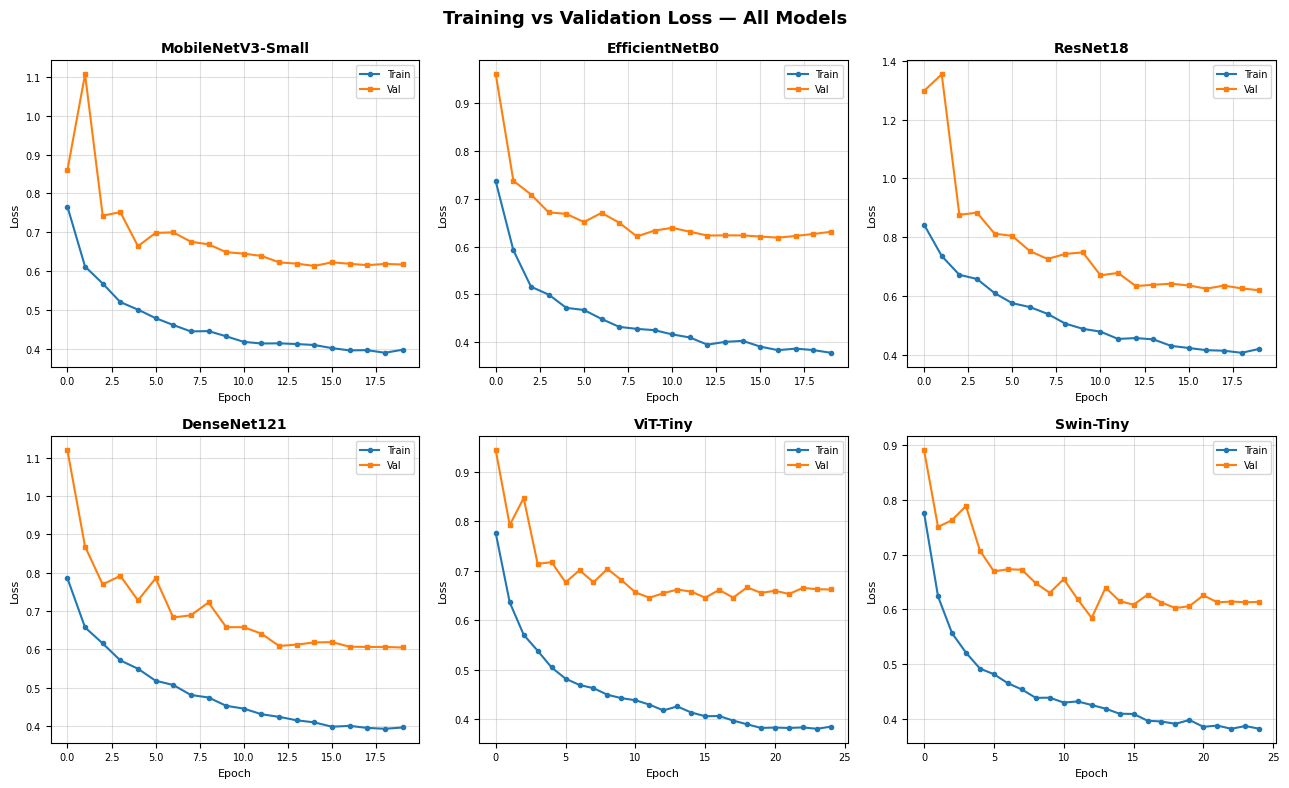

  saved → /kaggle/working/paper_outputs/plots/confusion_matrix_all.png / .pdf


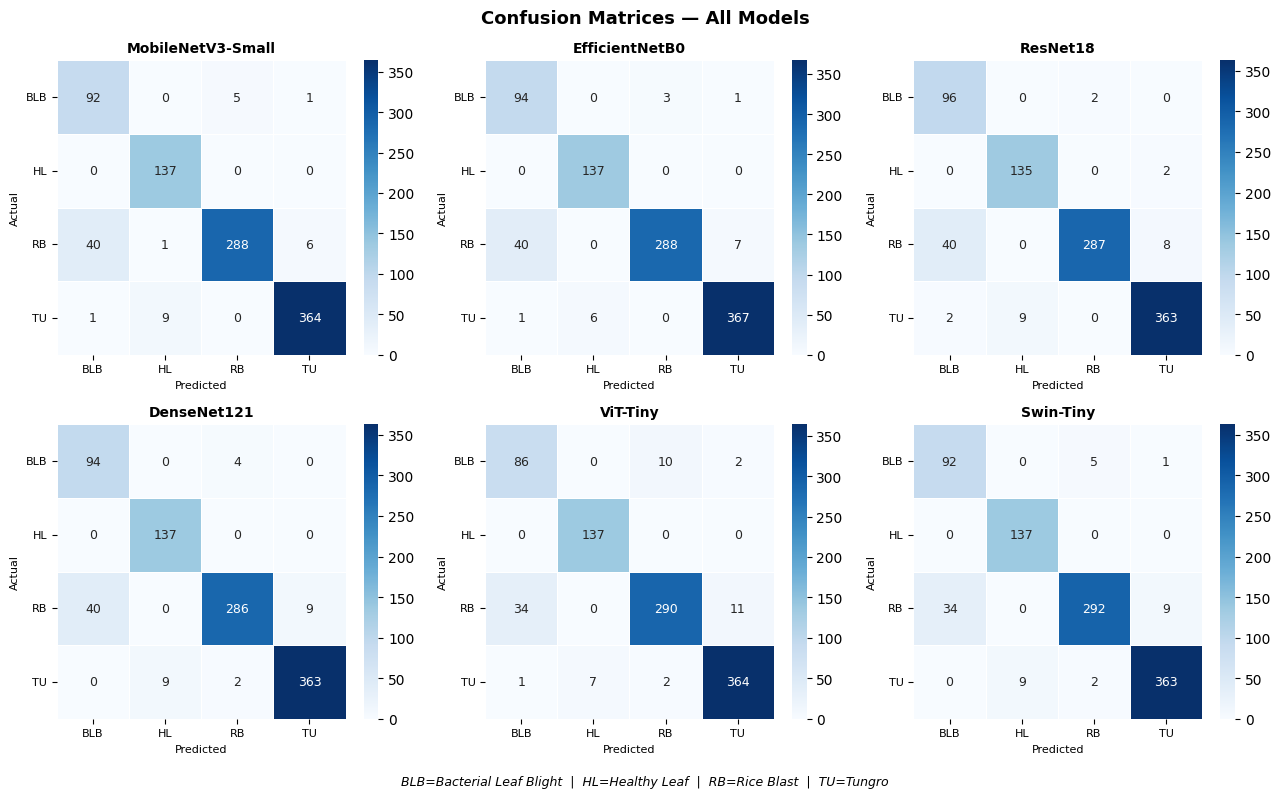

  saved → /kaggle/working/paper_outputs/plots/per_class_f1_comparison.png / .pdf


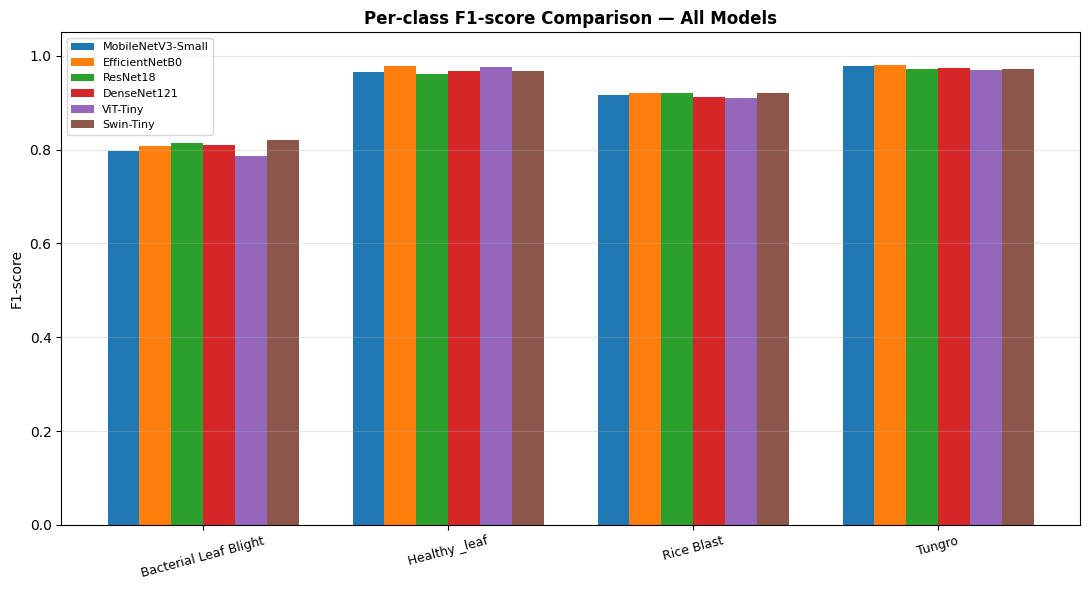

  saved → /kaggle/working/paper_outputs/plots/accuracy_vs_model_size.png / .pdf


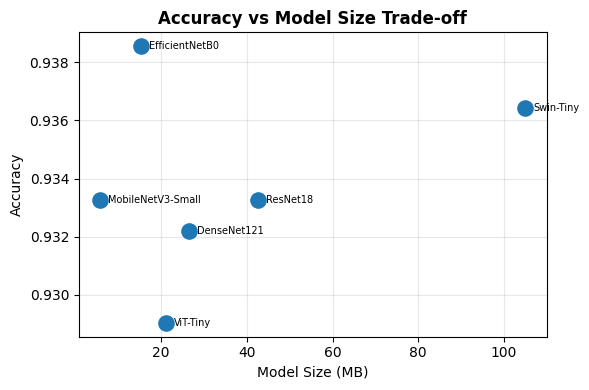

  saved → /kaggle/working/paper_outputs/plots/latency_comparison.png / .pdf


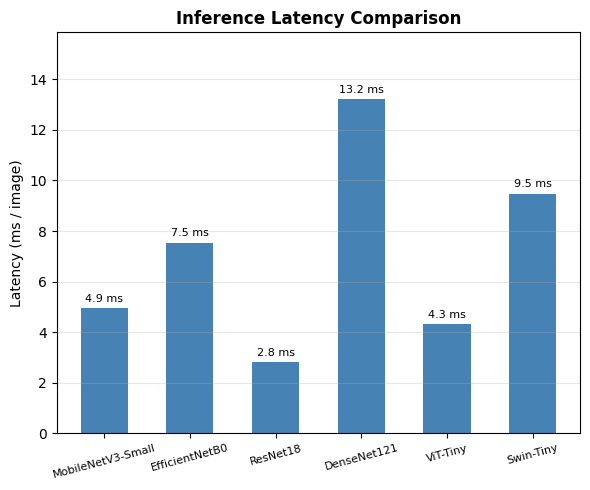


✅ Cell 17 complete — all plots saved (PNG + PDF)
   → /kaggle/working/paper_outputs/plots/


In [70]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 17 — All Evaluation Plots  (Loss · CM · F1 · Size · Latency)
# ══════════════════════════════════════════════════════════════════════════════

os.makedirs(os.path.join(OUT_DIR, "plots"),  exist_ok=True)
os.makedirs(os.path.join(OUT_DIR, "gradcam"), exist_ok=True)

plot_models = [
    "MobileNetV3-Small", "EfficientNetB0", "ResNet18",
    "DenseNet121",       "ViT-Tiny",       "Swin-Tiny"
]

short_labels = ["BLB", "HL", "RB", "TU"]

# ── helper: save both PNG + PDF ───────────────────────────────────────────────
def save_fig(fig, subfolder, filename):
    base = os.path.join(OUT_DIR, subfolder, filename)
    fig.savefig(base + ".png", dpi=300, bbox_inches="tight")
    fig.savefig(base + ".pdf",            bbox_inches="tight")
    print(f"  saved → {base}.png / .pdf")

# ── 1) Loss Curves ────────────────────────────────────────────────────────────
all_train_losses = {
    "MobileNetV3-Small": mobilenet_train_losses,
    "EfficientNetB0":    eff_train_losses,
    "ResNet18":          resnet_train_losses,
    "DenseNet121":       densenet_train_losses,
    "ViT-Tiny":          vit_train_losses,
    "Swin-Tiny":         swin_train_losses,
}
all_val_losses = {
    "MobileNetV3-Small": mobilenet_val_losses,
    "EfficientNetB0":    eff_val_losses,
    "ResNet18":          resnet_val_losses,
    "DenseNet121":       densenet_val_losses,
    "ViT-Tiny":          vit_val_losses,
    "Swin-Tiny":         swin_val_losses,
}

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes = axes.flatten()
for i, name in enumerate(plot_models):
    axes[i].plot(all_train_losses[name], label="Train", marker='o', markersize=3)
    axes[i].plot(all_val_losses[name],   label="Val",   marker='s', markersize=3)
    axes[i].set_title(name, fontsize=10, fontweight='bold')
    axes[i].set_xlabel("Epoch", fontsize=8)
    axes[i].set_ylabel("Loss",  fontsize=8)
    axes[i].legend(fontsize=7)
    axes[i].grid(True, alpha=0.4)
    axes[i].tick_params(labelsize=7)
plt.suptitle("Training vs Validation Loss — All Models",
             fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig(fig, "plots", "loss_curves")
plt.show()

# ── 2) Confusion Matrices ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes = axes.flatten()
for i, name in enumerate(plot_models):
    cm = all_model_metrics[name]["cm"]
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=short_labels, yticklabels=short_labels,
        ax=axes[i], annot_kws={"size": 9}, linewidths=0.5
    )
    axes[i].set_title(name, fontsize=10, fontweight='bold', pad=6)
    axes[i].set_xlabel("Predicted", fontsize=8)
    axes[i].set_ylabel("Actual",    fontsize=8)
    axes[i].tick_params(axis='x', labelsize=8)
    axes[i].tick_params(axis='y', labelsize=8, rotation=0)

legend_text = "BLB=Bacterial Leaf Blight  |  HL=Healthy Leaf  |  RB=Rice Blast  |  TU=Tungro"
plt.figtext(0.5, 0.01, legend_text, ha='center', fontsize=9, style='italic')
plt.suptitle("Confusion Matrices — All Models", fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 1])
save_fig(fig, "plots", "confusion_matrix_all")
plt.show()

# ── 3) Per-class F1 ───────────────────────────────────────────────────────────
x     = np.arange(len(class_names))
width = 0.13

fig, ax = plt.subplots(figsize=(11, 6))
for i, name in enumerate(plot_models):
    f1_scores = [all_reports[name][cls]["f1-score"] for cls in class_names]
    offset    = (i - 2.5) * width
    ax.bar(x + offset, f1_scores, width=width, label=name)

ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=15, fontsize=9)
ax.set_ylabel("F1-score")
ax.set_title("Per-class F1-score Comparison — All Models",
             fontsize=12, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
save_fig(fig, "plots", "per_class_f1_comparison")
plt.show()

# ── 4) Accuracy vs Model Size ─────────────────────────────────────────────────
acc  = [all_model_metrics[m]["accuracy"]  for m in plot_models]
size = [all_model_metrics[m]["size_mb"]   for m in plot_models]

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(size, acc, s=120, zorder=5)
for i, m in enumerate(plot_models):
    ax.annotate(m, (size[i], acc[i]),
                xytext=(6, 0), textcoords='offset points',
                fontsize=7, va='center')
ax.set_xlabel("Model Size (MB)")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy vs Model Size Trade-off",
             fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_fig(fig, "plots", "accuracy_vs_model_size")
plt.show()

# ── 5) Latency Comparison ─────────────────────────────────────────────────────
latencies = [all_model_metrics[m]["latency_ms"] for m in plot_models]

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(plot_models, latencies, color='steelblue', width=0.55)
ax.bar_label(bars, fmt='%.1f ms', fontsize=8, padding=3)
ax.set_ylabel("Latency (ms / image)")
ax.set_title("Inference Latency Comparison",
             fontsize=12, fontweight='bold')
ax.set_ylim(0, max(latencies) * 1.2)
ax.tick_params(axis='x', rotation=15, labelsize=8)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
save_fig(fig, "plots", "latency_comparison")
plt.show()

print("\n✅ Cell 17 complete — all plots saved (PNG + PDF)")
print(f"   → {os.path.join(OUT_DIR, 'plots')}/")

Finding representative samples …


  3%|█                               | 33/944 [00:00<00:17, 51.75it/s]


Classes found: ['Bacterial Leaf Blight', 'Healthy _leaf', 'Rice Blast', 'Tungro']
  saved → /kaggle/working/paper_outputs/gradcam/gradcam_7x5_grid.png / .pdf


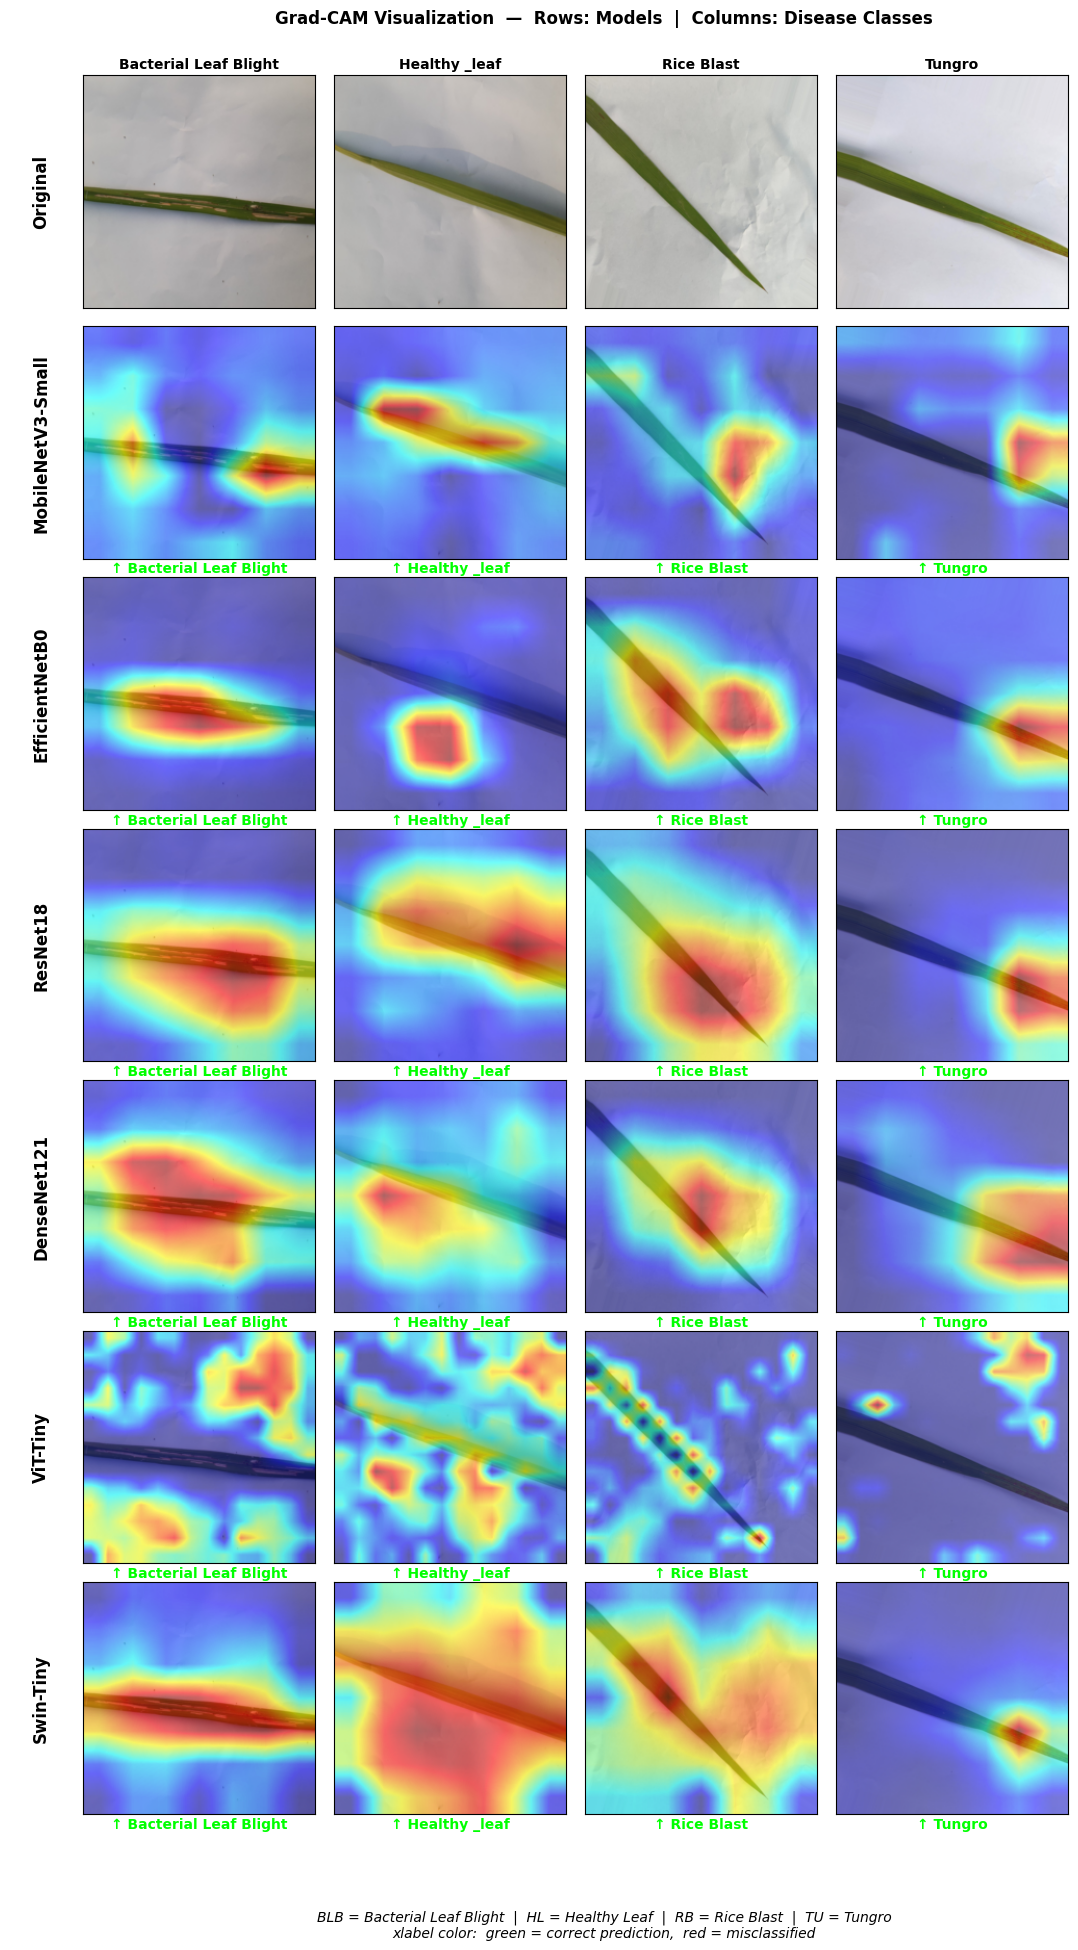


  All outputs saved → /kaggle/working/paper_outputs
  plots/loss_curves.png  +  .pdf
  plots/confusion_matrix_all.png  +  .pdf
  plots/per_class_f1_comparison.png  +  .pdf
  plots/accuracy_vs_model_size.png  +  .pdf
  plots/latency_comparison.png  +  .pdf
  gradcam/gradcam_7x5_grid.png  +  .pdf

✅ Cell 18 complete — Grad-CAM saved (PNG + PDF)


In [71]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 18 — Grad-CAM Visualization  
import math
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

inv_mean = np.array([0.485, 0.456, 0.406])
inv_std  = np.array([0.229, 0.224, 0.225])

def denormalize_image(img_tensor):
    img = img_tensor.permute(1, 2, 0).cpu().numpy()
    return np.clip((img * inv_std) + inv_mean, 0, 1)

# ── reshape transforms ────────────────────────────────────────────────────────
def reshape_transform_vit(tensor, height=14, width=14):
    tensor = tensor[:, 1:, :]          # remove CLS token
    result = tensor.reshape(tensor.size(0), height, width, tensor.size(2))
    return result.permute(0, 3, 1, 2)

def reshape_transform_swin(tensor):
    """
    timm newer  → (B, H, W, C) — already spatial
    timm older  → (B, L, C)    — needs reshape
    """
    if tensor.dim() == 4:
        return tensor.permute(0, 3, 1, 2)          # (B,H,W,C)→(B,C,H,W)
    B, L, C = tensor.shape
    H = W = int(math.sqrt(L))
    if H * W != L:
        return tensor.permute(0, 2, 1).unsqueeze(2) # fallback
    return tensor.reshape(B, H, W, C).permute(0, 3, 1, 2)

def get_pred(model, img_tensor):
    model.eval()
    with torch.no_grad():
        out = model(img_tensor.unsqueeze(0).to(device))
        return out.argmax(dim=1).item()

# ── model registry ────────────────────────────────────────────────────────────
gradcam_models = {
    "MobileNetV3-Small": model_mobilenet,
    "EfficientNetB0":    model_eff,
    "ResNet18":    model_resnet,
    "DenseNet121": model_densenet,
    "ViT-Tiny":    model_vit,
    "Swin-Tiny":   model_swin,
}
target_layers_map = {
    "MobileNetV3-Small": [model_mobilenet.features[-1]],
    "EfficientNetB0":    [model_eff.features[-1]],
    "ResNet18":    [model_resnet.layer4[-1]],
    "DenseNet121": [model_densenet.features[-1]],
    "ViT-Tiny":    [model_vit.blocks[-1].norm1],
    "Swin-Tiny":   [model_swin.backbone.norm],
}
reshape_map = {
    "ViT-Tiny":  reshape_transform_vit,
    "Swin-Tiny": reshape_transform_swin,
}

model_names = list(gradcam_models.keys())   # 6

# ── Find 1 correctly predicted sample per class (all 6 models agree) ─────────
print("Finding representative samples …")
seen_classes = {}
for idx in tqdm(range(len(test_ds)), ncols=70):
    img, label = test_ds[idx]
    if label in seen_classes:
        continue
    if all(get_pred(m, img) == label for m in gradcam_models.values()):
        seen_classes[label] = idx
    if len(seen_classes) == num_classes:
        break

sample_indices = [seen_classes[c] for c in sorted(seen_classes.keys())]
print("Classes found:", [class_names[test_ds[i][1]] for i in sample_indices])


n_rows  = len(model_names) + 1        # 7
n_cols  = len(sample_indices) + 1     # 5
cell_in = 2.7                         # inch per cell

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(n_cols * cell_in, n_rows * cell_in),
    gridspec_kw={'wspace': 0.01,'hspace': 0.08,
                 'width_ratios': [0.25] + [1] * len(sample_indices)}
)

# ── Row 0: Header row — Original images ──────────────────────────────────────
axes[0, 0].axis('off')
axes[0, 0].text(0.5, 0.5, "Original",
                ha='center', va='center',
                fontsize=12, fontweight='bold',
                rotation=90,
                transform=axes[0, 0].transAxes)

for col_idx, idx in enumerate(sample_indices, start=1):
    img, label = test_ds[idx]
    axes[0, col_idx].imshow(denormalize_image(img))
    axes[0, col_idx].set_xticks([])
    axes[0, col_idx].set_yticks([])
    axes[0, col_idx].set_title(class_names[label],
                                fontsize=10, fontweight='bold', pad=5)


for row_idx, name in enumerate(model_names, start=1):
    model = gradcam_models[name]
    model.eval()

    # ── Col 0: model name as centred rotated text — no image ──────────────
    axes[row_idx, 0].axis('off')
    axes[row_idx, 0].text(0.5, 0.5, name,
                           ha='center', va='center',
                           fontsize=12, fontweight='bold',
                           rotation=90,
                           transform=axes[row_idx, 0].transAxes)

    # ── Col 1–4: Grad-CAM heatmap for EVERY class (start=1 fixes Tungro) ──
    for col_idx, idx in enumerate(sample_indices, start=1):
        img, label   = test_ds[idx]
        rgb_img      = denormalize_image(img)
        input_tensor = img.unsqueeze(0).to(device)

        pred    = get_pred(model, img)
        reshape = reshape_map.get(name, None)

        cam = GradCAM(
            model=model,
            target_layers=target_layers_map[name],
            reshape_transform=reshape
        )
        grayscale = cam(
            input_tensor=input_tensor,
            targets=[ClassifierOutputTarget(pred)]
        )[0]
        cam_img = show_cam_on_image(rgb_img, grayscale, use_rgb=True)

        axes[row_idx, col_idx].imshow(cam_img)
        axes[row_idx, col_idx].set_xticks([])
        axes[row_idx, col_idx].set_yticks([])

        # prediction label (green = correct, red = wrong)
        color = 'lime' if pred == label else 'red'
        axes[row_idx, col_idx].set_xlabel(
            f"↑ {class_names[pred]}",
            fontsize=10, color=color, labelpad=2, fontweight='bold'
        )

# FIX 2: Remove any rogue colorbar/extra axes added by GradCAM internals
expected_axes = set(axes.flatten())
for ax in fig.axes[:]:          # iterate a shallow copy so removal is safe
    if ax not in expected_axes:
        ax.remove()

# ── Title + legend ────────────────────────────────────────────────────────────
plt.suptitle(
    "Grad-CAM Visualization  —  Rows: Models  |  Columns: Disease Classes",
    fontsize=12, fontweight='bold', y=1.005
)
legend_text = (
    "BLB = Bacterial Leaf Blight  |  HL = Healthy Leaf  "
    "|  RB = Rice Blast  |  TU = Tungro\n"
    "xlabel color:  green = correct prediction,  red = misclassified"
)
plt.figtext(0.5, -0.015, legend_text, ha='center', fontsize=10, style='italic')

# FIX 3: Replace plt.tight_layout() with subplots_adjust — no more UserWarning
fig.subplots_adjust(top=0.97, bottom=0.05, left=0.06, right=0.85,
                    wspace=0.01, hspace=0.8)

# ── Save PNG + PDF ────────────────────────────────────────────────────────────
save_fig(fig, "gradcam", "gradcam_7x5_grid")   # reuses save_fig() from Cell 17
plt.show()

# ── Final summary ─────────────────────────────────────────────────────────────
print("\n" + "="*55)
print("  All outputs saved →", OUT_DIR)
print("="*55)
for f in [
    "plots/loss_curves",
    "plots/confusion_matrix_all",
    "plots/per_class_f1_comparison",
    "plots/accuracy_vs_model_size",
    "plots/latency_comparison",
    "gradcam/gradcam_7x5_grid",
]:
    print(f"  {f}.png  +  .pdf")
print("="*55)
print("\n✅ Cell 18 complete — Grad-CAM saved (PNG + PDF)")